In [1]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch
import torch.nn as nn
import numpy as np 
import os

from core.models.vae import VAE_model, VAE_loss
from core.dataset import FilteredMNIST
from core.utils import extract_representation, plot_latent_space, plot_input_space

# Download and preprocess data

In [2]:
# MNIST Dataset transformation
mnist_transform = transforms.Compose([
    transforms.ToTensor(), # Converts to [0, 1] interval
    transforms.Lambda(lambda x: torch.flatten(x)) # Flattens the image to a 1D vector
])

# Download and load the MNIST dataset
full_train_dataset = datasets.MNIST(root='mnist_data', train=True, transform=mnist_transform, download=True)
print("Original size of the dataset: ", len(full_train_dataset))
filtered_labels = [0, 2, 4]

print("Filtered labels: ", filtered_labels)
train_dataset = FilteredMNIST(full_train_dataset, filtered_labels)
print("New size of the dataset: ", len(train_dataset))

batch_size = 256
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True,num_workers=4)

Original size of the dataset:  60000
Filtered labels:  [0, 2, 4]
New size of the dataset:  17723


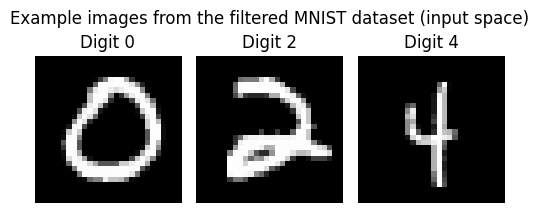

In [3]:
plot_input_space(train_loader, filtered_labels)

# Load VAE

In [4]:
# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Construct an artificial dataset
N_train, D = 17714, 28 * 28  # Number of training samples and dimensionality of the input

# Parameters of the VAE
d = 2  # The latent space dimension
activFun = nn.LeakyReLU(0.2)
H = 64
lambda_reg = 1e-7  # For the weights of the networks
epochs = 500
learning_rate = 2e-4
clipping_value = 1
batch_size = 128
r_max = 1  # au lieu de 1.0
warmup = int(0.5 * epochs)

In [5]:
# The model and the optimizer for the VAE
model = VAE_model(d, D, H, activFun).to(device)
optimizer_model = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=lambda_reg)

# Train VAE

In [13]:
X_train_list = []

for X, _ in train_loader:
    X_train_list.append(X)

X_train = torch.cat(X_train_list).cpu()

# Train the VAE with the new prior
ELBO = np.zeros((epochs, 1))

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_model,
    mode='min',
    factor=0.5,
    patience=20,
    verbose=True
)

for epoch in range(epochs):

    model.train()

    train_loss = 0
    train_loss_num = 0

    # Warmup annealing (epoch-level)
    r = min(r_max, epoch / warmup * r_max)

    for X_batch, _ in train_loader:

        X_batch = X_batch.to(device)

        mu_x, z_rep, mu_z, log_var_z = model(X_batch)

        loss, recon, kl = VAE_loss(
            x=X_batch,
            mu_x=mu_x,
            mu_z=mu_z,
            log_var_z=log_var_z,
            r=r
        )

        optimizer_model.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clipping_value
        )

        optimizer_model.step()

        train_loss += loss.item()
        train_loss_num += 1

    epoch_loss = train_loss / max(train_loss_num, 1)
    ELBO[epoch] = epoch_loss

    scheduler.step(epoch_loss)

    if epoch % 10 == 0:
        print(f"[Epoch {epoch}/{epochs}] total: {epoch_loss:.1f} | recon: {recon:.1f} | kl: {kl:.3f} | r: {r:.2f}")

print("Training finished")

/home/infres/court-22/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


[Epoch 0/500] total: 45.5 | recon: 34.3 | kl: 6.231 | r: 0.00
[Epoch 10/500] total: 20.6 | recon: 20.1 | kl: 8.433 | r: 0.04
[Epoch 20/500] total: 19.7 | recon: 19.0 | kl: 5.745 | r: 0.08
[Epoch 30/500] total: 19.4 | recon: 19.4 | kl: 5.981 | r: 0.12
[Epoch 40/500] total: 19.2 | recon: 17.9 | kl: 5.478 | r: 0.16
[Epoch 50/500] total: 19.0 | recon: 18.3 | kl: 5.320 | r: 0.20
[Epoch 60/500] total: 18.9 | recon: 17.3 | kl: 5.072 | r: 0.24
[Epoch 70/500] total: 18.9 | recon: 17.2 | kl: 4.821 | r: 0.28
[Epoch 80/500] total: 18.9 | recon: 16.7 | kl: 4.541 | r: 0.32
[Epoch 90/500] total: 18.9 | recon: 16.3 | kl: 4.453 | r: 0.36
[Epoch 100/500] total: 19.1 | recon: 17.6 | kl: 4.337 | r: 0.40
[Epoch 110/500] total: 19.1 | recon: 16.5 | kl: 4.319 | r: 0.44
[Epoch 120/500] total: 19.3 | recon: 17.4 | kl: 4.305 | r: 0.48
[Epoch 130/500] total: 19.4 | recon: 16.9 | kl: 4.233 | r: 0.52
[Epoch 140/500] total: 19.6 | recon: 16.4 | kl: 3.865 | r: 0.56
[Epoch 150/500] total: 19.7 | recon: 17.0 | kl: 4.0

In [14]:
# Save model
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "vae_model_mnist_024.pt")

torch.save(model.state_dict(), model_path)

print(f"Model saved in {model_path}")

Model saved in saved_models/vae_model_mnist_024.pt


## Sanity check: latent space

In [9]:
# if model already exists, load it
model_path = "saved_models/vae_model_mnist_024.pt"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print(f"Model loaded from {model_path}")

Model loaded from saved_models/vae_model_mnist_024.pt


In [10]:
# Extract the latent representations for the training data
Z, labels = extract_representation(model, train_loader, device)

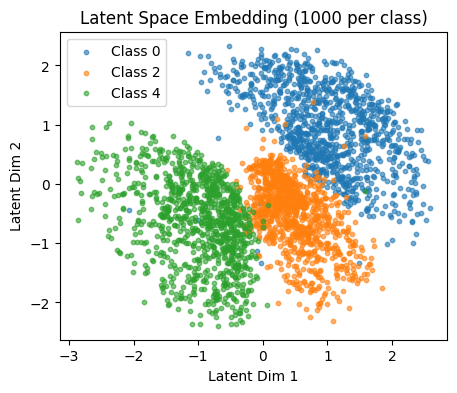

In [11]:
plot_latent_space(Z, labels)